## Integer Damath DynaQ

In [1]:
from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Dict, Any
import numpy as np
import copy
from collections import defaultdict, deque


In [2]:
Operator = Optional[str]  # '+', '-', 'x', '/' or None

@dataclass
class Piece:
    player: int  # 1 = Blue, -1 = Red
    value: int
    dama: bool = False

    def __repr__(self):
        # Convert B to blue emoji and R to red emoji for better visualization
        p = "🔵" if self.player == 1 else "🔴"
        val = f"{self.value:+d}" if self.value >= 0 else str(self.value)
        return f"{p}{'D' if self.dama else ''}{val}"
    
    
    def copy(self):
        return Piece(self.player, self.value, self.dama)

@dataclass
class Move:
    path: List[Tuple[int, int]]            # sequence of positions traversed
    captures: List[Tuple[int, int]]        # list of captured piece positions
    promotes: bool = False                 # whether the move results in promotion
    score_gain: int = 0                    # arithmetic reward from the move
    is_dama_capture: bool = False          # whether move made by dama
    is_multi_jump: bool = False            # whether multiple captures occurred

    def __repr__(self):
        cap_str = f" x{len(self.captures)}" if self.captures else ""
        promo = " (promo)" if self.promotes else ""
        return f"{self.path}{cap_str}{promo} +{self.score_gain}"



In [3]:
class DamathEnv:
    def __init__(self, rows=8, cols=8, operator_pattern=None):
        self.R = rows
        self.C = cols
        assert rows == 8 and cols == 8, "Currently implemented for 8x8 boards."
        # Operators on playable squares. Default pattern similar to provided image if None.
        if operator_pattern is None:
            operator_pattern = self.default_operator_board()
        self.op_board = operator_pattern
        # Piece board: dict (r,c)->Piece
        self.pieces: Dict[Tuple[int, int], Piece] = {}
        # Scores cumulative per player
        self.scores = {1: 0.0, -1: 0.0}
        self.to_move = 1  # 1 starts (blue on top)
        self.history_states = deque(maxlen=50)  # for repetition detection (store simple board hashes)

        # initialize sample starting board if user wants. We'll provide a helper to set initial config.
        self.init_default_integer_setup()

    def default_operator_board(self):
        # Create operator layout (8x8) using a repeating pattern similar to the uploaded assets.
        # Operators placed on playable squares (r+c)%2==1.
        ops = ['x', '/', '-', '+']  # cycle
        board = [[None for _ in range(self.C)] for __ in range(self.R)]
        for r in range(self.R):
            for c in range(self.C):
                if (r + c) % 2 == 1:
                    # choose operator based on some pattern; rotate every cell
                    board[r][c] = ops[(r + 2 * c) % len(ops)]
                else:
                    board[r][c] = None
        return board

    def init_default_integer_setup(self):
        # Initialize pieces according to the "integer damath" sample. We'll follow a symmetric-ish layout.
        # Blue (player=1) on top three rows playable squares, Red (player=-1) on bottom three rows.
        self.pieces = {}
        # sample integer values, you can customize to exact image mapping
        blue_values = [
            [-11, 8, -5, 2],
            [0, -3, 10, -7],
            [-9, 6, -1, 4],
        ]
        red_values = [
            [4, -1, 6, -9],
            [-7, 10, -3, 0],
            [2, -5, 8, -11]
        ]

        def playable_positions_on_row(r):
            # playable cols where (r+c)%2==1
            return [c for c in range(self.C) if (r + c) % 2 == 1]

        # Blue top 3 rows
        for i, r in enumerate(range(0, 3)):
            cols = playable_positions_on_row(r)
            vals = blue_values[i]
            for j, c in enumerate(cols[:len(vals)]):
                self.pieces[(r, c)] = Piece(player=1, value=vals[j], dama=False)
        # Red bottom 3 rows
        for i, r in enumerate(range(5, 8)):
            cols = playable_positions_on_row(r)
            vals = red_values[i - 0] if i < len(red_values) else []
            for j, c in enumerate(cols[:len(vals)]):
                self.pieces[(r, c)] = Piece(player=-1, value=vals[j], dama=False)
        # reset scores and to_move
        self.scores = {1: 0.0, -1: 0.0}
        self.to_move = 1
        self.history_states.clear()
        self.record_state()

    def copy(self):
        newenv = DamathEnv(self.R, self.C)
        newenv.op_board = copy.deepcopy(self.op_board)
        newenv.pieces = {k: v.copy() for k, v in self.pieces.items()}
        newenv.scores = dict(self.scores)
        newenv.to_move = self.to_move
        newenv.history_states = copy.deepcopy(self.history_states)
        return newenv

    def in_bounds(self, r, c):
        return 0 <= r < self.R and 0 <= c < self.C

    def is_playable(self, r, c):
        return self.in_bounds(r, c) and ((r + c) % 2 == 1)

    def get_piece(self, r, c) -> Optional[Piece]:
        return self.pieces.get((r, c))

    def remove_piece(self, r, c):
        if (r, c) in self.pieces:
            del self.pieces[(r, c)]

    def move_piece(self, from_rc, to_rc):
        p = self.pieces.pop(from_rc)
        self.pieces[to_rc] = p
        return p

    def record_state(self):
        # Simple hash of pieces positions and values and to_move for repetition detection
        items = tuple(sorted([(pos, piece.player, piece.value, piece.dama) for pos, piece in self.pieces.items()]))
        key = (self.to_move, items)
        self.history_states.append(key)

    # ----------------------------- Operators & arithmetic -----------------------------
    def op_at(self, r, c):
        if not self.is_playable(r, c):
            return None
        return self.op_board[r][c]

    def apply_operator(self, op: str, a: int, b: int):
        if op == '+':
            return a + b
        if op == '-':
            return a - b
        if op == 'x' or op == 'X' or op == '*':
            return a * b
        if op == '/':
            # integer division semantics: handle division by zero and prefer integer division rounding toward zero
            if b == 0:
                # define a penalty or large negative? For now, return 0 to avoid crash.
                return 0
            return int(a / b)
        raise ValueError("Unknown op " + str(op))

    # ----------------------------- Movement and capture generation -----------------------------
    def generate_all_moves(self, player: int):
        """
        Returns a list of Move objects representing all legal moves for player.
        Enforces mandatory captures and priority rules described in prompt.
        """
        # 1) Find all capture sequences for every piece
        capture_moves = []
        for pos, piece in list(self.pieces.items()):
            if piece.player != player:
                continue
            caps = self._generate_captures_from(pos, piece)
            capture_moves.extend(caps)
        if len(capture_moves) > 0:
            # enforce capture priority: (1) max captures, (2) if tie, dama priority, (3) if regular has more captures than dama, regular wins
            max_cap = max(len(m.captures) for m in capture_moves)
            # filter moves with max captures
            maxcap_moves = [m for m in capture_moves if len(m.captures) == max_cap]
            # among tied moves, if any are from dama pieces and any from regular, prefer dama (unless regular has strictly more captures in other moves)
            # but since we already filtered to max_cap, only need to prefer dama among ties => prefer moves with piece.dama True if any
            if any(self.pieces[m.path[0]].dama for m in maxcap_moves):
                maxcap_moves = [m for m in maxcap_moves if self.pieces[m.path[0]].dama]
            # compute score_gain for each move using current op board and multipliers
            for m in maxcap_moves:
                m.score_gain = self._compute_move_score(m, player)
            return maxcap_moves
        # 2) If no captures, generate simple moves including dama moves
        simple_moves = []
        for pos, piece in list(self.pieces.items()):
            if piece.player != player:
                continue
            sms = self._generate_simple_from(pos, piece)
            simple_moves.extend(sms)
        # mark score_gain zero for these
        for m in simple_moves:
            m.score_gain = 0.0
        return simple_moves

    def _generate_simple_from(self, pos, piece: Piece):
        r, c = pos
        moves = []
        if piece.dama:
            # dama can move any distance along diagonals (like king in international draughts)
            for dr, dc in [(-1, -1), (-1, 1), (1, -1), (1, 1)]:
                step = 1
                while True:
                    nr = r + dr * step; nc = c + dc * step
                    if not self.in_bounds(nr, nc) or not self.is_playable(nr, nc):
                        break
                    if (nr, nc) in self.pieces:
                        break
                    path = [(r, c), (nr, nc)]
                    promotes = self._check_promotion(nr, piece.player)
                    moves.append(Move(path=path, captures=[], promotes=promotes))
                    step += 1
        else:
            # regular piece: forward-only? In Damath, regular pieces can move diagonally forward one space.
            # We assume player=1 moves 'down' (increasing row), player=-1 moves 'up' (decreasing row).
            dr = 1 if piece.player == 1 else -1
            for dc in (-1, 1):
                nr = r + dr; nc = c + dc
                if not self.in_bounds(nr, nc) or not self.is_playable(nr, nc):
                    continue
                if (nr, nc) in self.pieces:
                    continue
                path = [(r, c), (nr, nc)]
                promotes = self._check_promotion(nr, piece.player)
                moves.append(Move(path=path, captures=[], promotes=promotes))
        return moves

    def _generate_captures_from(self, pos, piece: Piece):
        # returns all capture sequences starting from this piece (as Move objects)
        results = []
        r, c = pos

        if piece.dama:
            # long-range captures: for each diagonal, find opponent pieces and possible landing squares beyond.
            for dr, dc in [(-1, -1), (-1, 1), (1, -1), (1, 1)]:
                step = 1
                while True:
                    mr = r + dr * step; mc = c + dc * step
                    if not self.in_bounds(mr, mc) or not self.is_playable(mr, mc):
                        break
                    if (mr, mc) in self.pieces:
                        target = self.pieces[(mr, mc)]
                        if target.player == piece.player:
                            break  # blocked by own piece
                        # find landing squares beyond (must be empty)
                        land_step = 1
                        while True:
                            lr = mr + dr * land_step; lc = mc + dc * land_step
                            if not self.in_bounds(lr, lc) or not self.is_playable(lr, lc):
                                break
                            if (lr, lc) in self.pieces:
                                break
                            # found a possible landing square
                            new_env = self.copy()
                            captured_piece = new_env.pieces.pop((mr, mc))
                            moved_piece = new_env.pieces.pop((r, c))
                            new_env.pieces[(lr, lc)] = moved_piece
                            further = new_env._generate_captures_from((lr, lc), moved_piece)
                            if len(further) == 0:
                                m = Move(path=[(r, c), (lr, lc)], captures=[(mr, mc, captured_piece)], promotes=False)
                                results.append(m)
                            else:
                                for fm in further:
                                    m = Move(path=[(r, c)] + fm.path, captures=[(mr, mc, captured_piece)] + fm.captures, promotes=False)
                                    results.append(m)
                            land_step += 1
                        break  # only consider the first opponent piece along diagonal for long-range capture
                    else:
                        step += 1

        else:
            # regular piece captures: check adjacent diagonals for opponent piece and landing square beyond
            for dr, dc in [(-1, -1), (-1, 1), (1, -1), (1, 1)]:
                ar = r + dr; ac = c + dc  # adjacent
                lr = r + 2 * dr; lc = c + 2 * dc  # landing beyond
                if not self.in_bounds(ar, ac) or not self.is_playable(ar, ac):
                    continue
                if (ar, ac) not in self.pieces:
                    continue
                if self.pieces[(ar, ac)].player == piece.player:
                    continue
                if not self.in_bounds(lr, lc) or not self.is_playable(lr, lc):
                    continue
                if (lr, lc) in self.pieces:
                    continue
                # simulate capture and recurse
                new_env = self.copy()
                captured_piece = new_env.pieces.pop((ar, ac))
                moved_piece = new_env.pieces.pop((r, c))
                new_env.pieces[(lr, lc)] = moved_piece
                further = new_env._generate_captures_from((lr, lc), moved_piece)
                if len(further) == 0:
                    m = Move(path=[(r, c), (lr, lc)], captures=[(ar, ac, captured_piece)], promotes=self._check_promotion(lr, piece.player))
                    results.append(m)
                else:
                    for fm in further:
                        m = Move(path=[(r, c)] + fm.path, captures=[(ar, ac, captured_piece)] + fm.captures, promotes=self._check_promotion(fm.path[-1][0], piece.player))
                        results.append(m)
        # remove duplicate sequences (same path) - dedupe by path and captured coordinates
        uniq = {}
        for m in results:
            key = (tuple(m.path), tuple((cr, cc, cp.value) for cr, cc, cp in m.captures))
            if key not in uniq or len(uniq[key].captures) < len(m.captures):
                uniq[key] = m
        return list(uniq.values())

    def _compute_move_score(self, move: Move, mover_player: int):
        # compute arithmetic score gain to mover for a capture move following rules:
        # - each captured piece adds op(own_value, captured_value) where op is operator on the landing square of that jump
        # - for dama captures, double score; if both dama, quadruple for that take.
        # - if a dama is taken by regular, the score is doubled as well (we handle multiplier on capture event)
        total = 0.0
        mover_start = move.path[0]
        mover_piece = self.pieces.get(mover_start)
        mover_is_dama = mover_piece.dama if mover_piece else False
        mover_value = mover_piece.value if mover_piece else 0
        # For each capture in sequence, determine operator at landing square (the square after the specific jump)
        for i, (cap_r, cap_c, cap_piece) in enumerate(move.captures):
            landing = move.path[1 + i] if len(move.path) > 1 + i else move.path[-1]
            op = self.op_at(*landing)
            base = self.apply_operator(op, mover_value, cap_piece.value)
            mult = 1
            if mover_is_dama and cap_piece.dama:
                mult = 4
            elif mover_is_dama:
                mult = 2
            elif cap_piece.dama:
                mult = 2
            total += base * mult
        return total

    def _check_promotion(self, r, player):
        # If a piece reaches opposing end (row 7 for player=1, row 0 for player=-1), it is promoted
        if player == 1 and r == self.R - 1:
            return True
        if player == -1 and r == 0:
            return True
        return False

    # ----------------------------- Apply Move -----------------------------
    def apply_move(self, move: "Move", verbose=False):
        """
        Apply a move and update board state + cumulative self.scores.
        Immediate reward is disabled — returns 0.0 every call.
        """
        player = self.to_move

        if len(move.captures) == 0:
            frm, to = move.path[0], move.path[-1]
            piece = self.pieces.pop(frm)
            self.pieces[to] = piece

            if self._check_promotion(to[0], piece.player) and not piece.dama:
                piece.dama = True

        else:
            frm = move.path[0]
            mover = self.pieces.pop(frm)
            current_pos = frm
            total_gain = 0.0

            for i, (cap_r, cap_c, cap_piece_snapshot) in enumerate(move.captures):
                landing = move.path[1 + i] if 1 + i < len(move.path) else move.path[-1]
                op = self.op_at(*landing)
                captured_piece = self.pieces.pop((cap_r, cap_c))
                base = self.apply_operator(op, mover.value, captured_piece.value)

                mult = 1
                if mover.dama and captured_piece.dama:
                    mult = 4
                elif mover.dama or captured_piece.dama:
                    mult = 2

                total_gain += base * mult
                current_pos = landing

            self.pieces[current_pos] = mover
            if self._check_promotion(current_pos[0], mover.player) and not mover.dama:
                mover.dama = True
            self.scores[mover.player] += total_gain

        self.to_move *= -1
        self.record_state()

        if verbose:
            print(f"[Player {player}] applied move, scores={self.scores}")
        return 0.0

    # ----------------------------- Terminal Reward -----------------------------
    def compute_final_reward_for(self, player: int = 1, alpha: float = 0.7, K: float = 100.0):
        """
        Compute final combined reward for `player`:
            final_reward = α * binary_outcome + (1 - α) * tanh((score_diff)/K)
            + capture rewards + promotion rewards - step penalty
        Returns (final_reward, winner, final_scores)
        """
        final_scores, winner = self.final_scores_and_winner()
        p_score = final_scores.get(player, 0.0)
        o_score = final_scores.get(-player, 0.0)

        # Start with base reward
        reward = 0.0

        # Immediate feedback for captures (if you track captures per player)
        if hasattr(self, 'captures') and player in getattr(self, 'captures', {}):
            if len(self.captures[player]) > 0:
                reward += 0.1 * (p_score / 10.0)  # Scaled by normalized score

        # Promotion reward (if you track promotions)
        if hasattr(self, 'promotions') and getattr(self, 'promotions', 0) > 0:
            reward += 0.3 * getattr(self, 'promotions', 0)

        # Small step penalty to encourage shorter games
        reward -= 0.01

        # If terminal, add final outcome
        if self.game_over():
            # Binary component
            if winner == player:
                reward += 1.0
            elif winner == -player:
                reward -= 1.0
            # Note: if draw (winner == 0), no additional reward

        # Normalized score difference
        norm_diff = float(np.tanh((p_score - o_score) / K))
        final_reward = float(alpha * reward + (1 - alpha) * norm_diff)
        final_reward = float(np.clip(final_reward, -1.0, 1.0))

        return final_reward, winner, final_scores

    # ----------------------------- Game end and scoring -----------------------------
    def legal_moves_exist(self, player: int):
        return len(self.generate_all_moves(player)) > 0

    def game_over(self):
        # game over if current player to move has no moves or only one player's chips remain or repetition or stalemate
        if not self.legal_moves_exist(self.to_move):
            return True
        # if only chips of one player remain
        players_present = set(p.player for p in self.pieces.values())
        if len(players_present) <= 1:
            return True
        # repetition detection (simple): if last 6 states repeated pattern
        hist = list(self.history_states)
        if len(hist) >= 8:
            counts = defaultdict(int)
            for h in hist:
                counts[h] += 1
                if counts[h] >= 4:
                    return True
        return False

    def final_scores_and_winner(self):
        # Add remaining pieces to their player's cumulative scores (dama doubled)
        final_scores = dict(self.scores)
        for (r, c), piece in self.pieces.items():
            val = piece.value * (2 if piece.dama else 1)
            final_scores[piece.player] += val
        # Determine winner
        if final_scores[1] > final_scores[-1]:
            winner = 1
        elif final_scores[1] < final_scores[-1]:
            winner = -1
        else:
            winner = 0
        return final_scores, winner

    # ----------------------------- Utilities -----------------------------
    def print_board(self):
        # Create board grid with operators and pieces
        grid = [[" ." for _ in range(self.C)] for __ in range(self.R)]
        for y in range(self.R):
            for x in range(self.C):
                if not self.is_playable(y, x):
                    grid[y][x] = "##"
                else:
                    op = self.op_at(y, x)
                    grid[y][x] = f" {op}"
        # Place pieces
        for (y, x), piece in self.pieces.items():
            sym = '🔵' if piece.player == 1 else '🔴'
            if piece.dama:
                sym += 'K'
            grid[y][x] = f"{sym}{piece.value:02d}" if piece.value >= 0 else f"{sym}{piece.value}"

        # Print column headers
        print("\n     " + " ".join([f"{x:>4}" for x in range(self.C)]))
        print("     " + "----" * self.C)

        # Print from top (highest y) to bottom (y=0)
        for y in reversed(range(self.R)):
            row_str = " ".join(f"{cell:>4}" for cell in grid[y])
            print(f"{y:>2} | {row_str} | {y:>2}")

        print("     " + "----" * self.C)
        print("     " + " ".join([f"{x:>4}" for x in range(self.C)]))


In [4]:
# Operator layout: (y, x) format
# y=0 is bottom row, y=7 is top row

operator_pattern_official = [
    ['x', '-', '/', 'x', '-', '+', '+', 'x'],
    ['-', '/', '-', 'x', '-', '+', 'x', '-'],
    ['-', '+', '+', '+', 'x', 'x', '/', '+'],
    ['x', '+', '+', '-', 'x', '/', '+', 'x'],
    ['x', '-', '/', 'x', '-', '-', '+', 'x'],
    ['-', '/', 'x', 'x', '-', '+', 'x', '-'],
    ['-', 'x', '+', '+', 'x', 'x', '/', '+'],
    ['+', '/', '-', '-', 'x', '/', '+', 'x']
]

env = DamathEnv(rows = 8, cols = 8, operator_pattern=operator_pattern_official)
env.print_board()
moves = env.generate_all_moves(env.to_move)
print("\nAvailable moves for player", env.to_move, "->", len(moves))
for move in moves:
    start = move.path[0]
    end = move.path[-1]
    piece = env.pieces.get(start, None)
    if piece:
        piece_type = "Dama" if piece.dama else "Regular"
        # Swap (y, x) to (x, y) for readability
        print(f"{piece_type} {piece.value:+d} at ({start[1]}, {start[0]}) -> ({end[1]}, {end[0]}) | ΔScore: {move.score_gain:+.1f}")
    else:
        print(f"Unknown piece at ({start[1]}, {start[0]}) -> ({end[1]}, {end[0]}) | ΔScore: {move.score_gain:+.1f}")




        0    1    2    3    4    5    6    7
     --------------------------------
 7 |  🔴02   ##  🔴-5   ##  🔴08   ## 🔴-11   ## |  7
 6 |   ##  🔴-7   ##  🔴10   ##  🔴-3   ##  🔴00 |  6
 5 |  🔴04   ##  🔴-1   ##  🔴06   ##  🔴-9   ## |  5
 4 |   ##    -   ##    x   ##    -   ##    x |  4
 3 |    x   ##    +   ##    x   ##    +   ## |  3
 2 |   ##  🔵-9   ##  🔵06   ##  🔵-1   ##  🔵04 |  2
 1 |  🔵00   ##  🔵-3   ##  🔵10   ##  🔵-7   ## |  1
 0 |   ## 🔵-11   ##  🔵08   ##  🔵-5   ##  🔵02 |  0
     --------------------------------
        0    1    2    3    4    5    6    7

Available moves for player 1 -> 7
Regular -9 at (1, 2) -> (0, 3) | ΔScore: +0.0
Regular -9 at (1, 2) -> (2, 3) | ΔScore: +0.0
Regular +6 at (3, 2) -> (2, 3) | ΔScore: +0.0
Regular +6 at (3, 2) -> (4, 3) | ΔScore: +0.0
Regular -1 at (5, 2) -> (4, 3) | ΔScore: +0.0
Regular -1 at (5, 2) -> (6, 3) | ΔScore: +0.0
Regular +4 at (7, 2) -> (6, 3) | ΔScore: +0.0


In [5]:
operator_pattern_official = [
    ['x', '+', '/', '-', '-', '/', '+', 'x'],
    ['-', '/', '+', 'x', 'x', '+', '/', '-'],
    ['-', '/', '+', 'x', 'x', '+', '/', '-'],
    ['x', '+', '/', '-', '-', '/', '+', 'x'],
    ['x', '+', '/', '-', '-', '/', '+', 'x'],
    ['-', '/', '+', 'x', 'x', '+', '/', '-'],
    ['-', '/', '+', 'x', 'x', '+', '/', '-'],
    ['x', '/', '/', '-', '-', '/', '+', 'x']
]

In [6]:
# Print empty board with no pieces, just operators
env_empty = DamathEnv(rows = 8, cols = 8, operator_pattern=operator_pattern_official)
env_empty.pieces = {}  # clear pieces

In [7]:
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

# create a unique run folder
run_name = f"runs/damath_selfplay_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
writer = SummaryWriter(run_name)

In [8]:
from collections import deque
import random

class ReplayBuffer:
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)

    def add(self, examples):
        """Add list of examples [(state, pi, z, mover), ...]"""
        self.buffer.extend(examples)

    def sample(self, batch_size):
        """Randomly sample a batch of examples"""
        batch = random.sample(self.buffer, batch_size)
        return batch

    def __len__(self):
        return len(self.buffer)


In [9]:
import math
import random
import time
import copy
from collections import defaultdict, deque
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

# ----------------------- Playable squares mapping ------------------------
PLAYABLE_POS = [(r, c) for r in range(8) for c in range(8) if (r + c) % 2 == 1]
POS_TO_IDX = {pos: i for i, pos in enumerate(PLAYABLE_POS)}
IDX_TO_POS = {i: pos for pos, i in POS_TO_IDX.items()}
ACTION_SIZE = len(PLAYABLE_POS) * len(PLAYABLE_POS)

def move_to_index(move):
    start = move.path[0]
    end = move.path[-1]
    s_idx = POS_TO_IDX[start]
    e_idx = POS_TO_IDX[end]
    return s_idx * len(PLAYABLE_POS) + e_idx

def index_to_move_index_pair(idx):
    n = len(PLAYABLE_POS)
    s = idx // n
    e = idx % n
    return s, e

def encode_state(env):
    """Encode state as 9-channel tensor"""
    C, H, W = 9, 8, 8
    state = np.zeros((C, H, W), dtype=np.float32)
    
    for (y, x), piece in env.pieces.items():
        if piece.player == 1:
            state[1 if piece.dama else 0, y, x] = 1.0
            state[4, y, x] = piece.value / 12.0
        else:
            state[3 if piece.dama else 2, y, x] = 1.0
            state[5, y, x] = piece.value / 12.0
    
    op_map = {'+': 0.25, '-': 0.5, 'x': 0.75, 'X': 0.75, '*': 0.75, '/': 1.0, '÷': 1.0}
    for y in range(8):
        for x in range(8):
            if env.is_playable(y, x):
                state[6, y, x] = op_map.get(env.op_board[y][x], 0.0)
    
    state[7, :, :] = 1.0 if env.to_move == 1 else 0.0
    blue = env.scores.get(1, 0.0)
    red = env.scores.get(-1, 0.0)
    state[8, :, :] = (blue - red) / 100.0
    return state

# ----------------------- Q-Network ------------------------
class QNetwork(nn.Module):
    def __init__(self, in_ch=9, board_h=8, board_w=8, action_size=ACTION_SIZE):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.bn2 = nn.BatchNorm2d(128)
        self.bn3 = nn.BatchNorm2d(128)
        
        # Q-value head
        self.q_conv = nn.Conv2d(128, 64, kernel_size=1)
        self.q_fc1 = nn.Linear(64 * board_h * board_w, 512)
        self.q_fc2 = nn.Linear(512, action_size)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        
        q = F.relu(self.q_conv(x))
        q = q.view(q.size(0), -1)
        q = F.relu(self.q_fc1(q))
        q = self.q_fc2(q)
        return q

# ----------------------- Model Network ------------------------
class ModelNetwork(nn.Module):
    def __init__(self, in_ch=9, board_h=8, board_w=8, action_size=ACTION_SIZE):
        super().__init__()
        
        # State encoder
        self.state_conv1 = nn.Conv2d(in_ch, 64, kernel_size=3, padding=1)
        self.state_conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        
        # Action embedding
        self.action_embed = nn.Embedding(action_size, 128)
        
        # Combined prediction
        self.pred_conv1 = nn.Conv2d(256, 128, kernel_size=3, padding=1)
        self.pred_conv2 = nn.Conv2d(128, 64, kernel_size=3, padding=1)
        self.pred_conv3 = nn.Conv2d(64, in_ch, kernel_size=3, padding=1)
        
        # Reward prediction
        self.reward_fc1 = nn.Linear(128 * board_h * board_w, 256)
        self.reward_fc2 = nn.Linear(256, 1)

    def forward(self, state, action_idx):
        B = state.size(0)
        
        # Encode state
        s = F.relu(self.state_conv1(state))
        s = F.relu(self.state_conv2(s))
        
        # Encode action
        a = self.action_embed(action_idx)
        a = a.view(B, 128, 1, 1).expand(-1, -1, 8, 8)
        
        # Concatenate
        combined = torch.cat([s, a], dim=1)
        
        # Predict next state
        next_state = F.relu(self.pred_conv1(combined))
        next_state = F.relu(self.pred_conv2(next_state))
        next_state = self.pred_conv3(next_state)
        
        # Predict reward
        flat = s.view(B, -1)
        reward = F.relu(self.reward_fc1(flat))
        reward = self.reward_fc2(reward).squeeze(-1)
        
        return next_state, reward

# ----------------------- Dyna-Q Agent ------------------------
class DynaQAgent:
    def __init__(self, q_net, model_net, model_optimizer, epsilon=0.1, alpha=0.001, 
                 gamma=0.95, planning_steps=10):
        """
        Args:
            q_net: Q-Network for value estimation
            model_net: Model Network for environment dynamics
            model_optimizer: Optimizer for the model network (IMPORTANT!)
            epsilon: Exploration rate
            alpha: Q-network learning rate
            gamma: Discount factor
            planning_steps: Number of planning steps per real step
        """
        self.q_net = q_net
        self.model_net = model_net
        self.model_optimizer = model_optimizer  # ✅ ADD THIS
        self.epsilon = epsilon
        self.alpha = alpha
        self.gamma = gamma
        self.planning_steps = planning_steps
        
        self.q_optimizer = optim.Adam(q_net.parameters(), lr=alpha)
        
        # Experience buffer
        self.experience_buffer = deque(maxlen=10000)

    def get_legal_mask(self, env):
        """Create mask for legal actions"""
        legal_moves = env.generate_all_moves(env.to_move)
        legal_indices = [move_to_index(m) for m in legal_moves]
        mask = np.zeros(ACTION_SIZE, dtype=np.float32)
        mask[legal_indices] = 1.0
        return mask, legal_moves, legal_indices

    def select_action(self, env, training=True):
        """Epsilon-greedy action selection"""
        mask, legal_moves, legal_indices = self.get_legal_mask(env)
        
        if not legal_moves:
            return None, None
        
        # Epsilon-greedy
        if training and random.random() < self.epsilon:
            chosen_idx = random.choice(legal_indices)
        else:
            state = encode_state(env)
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(next(self.q_net.parameters()).device)
            
            with torch.no_grad():
                q_values = self.q_net(state_tensor).squeeze(0).cpu().numpy()
            
            q_values = q_values * mask - (1 - mask) * 1e9
            chosen_idx = np.argmax(q_values)
        
        # Convert to move
        s_idx, e_idx = index_to_move_index_pair(chosen_idx)
        start = IDX_TO_POS[s_idx]
        end = IDX_TO_POS[e_idx]
        
        chosen_move = next((m for m in legal_moves if m.path[0] == start and m.path[-1] == end), 
                          random.choice(legal_moves))
        
        return chosen_move, chosen_idx

    def train_model_step(self, state, action_idx, reward, next_state):
        """Train model on single transition - called immediately after each step"""
        device = next(self.model_net.parameters()).device
        
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        action_tensor = torch.tensor([action_idx], dtype=torch.long).to(device)
        next_state_tensor = torch.tensor(next_state, dtype=torch.float32).unsqueeze(0).to(device)
        reward_tensor = torch.tensor([reward], dtype=torch.float32).to(device)
        
        # Forward pass
        pred_next_state, pred_reward = self.model_net(state_tensor, action_tensor)
        
        # Calculate losses
        state_loss = F.mse_loss(pred_next_state, next_state_tensor)
        reward_loss = F.mse_loss(pred_reward, reward_tensor)
        loss = state_loss + reward_loss
        
        # Backward pass
        self.model_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.model_net.parameters(), 1.0)
        self.model_optimizer.step()
        
        return loss.item()

    def update_q(self, state, action_idx, reward, next_state, done, next_legal_mask):
        """Q-learning update"""
        device = next(self.q_net.parameters()).device
        
        state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
        next_state_tensor = torch.tensor(next_state, dtype=torch.float32).unsqueeze(0).to(device)
        action_tensor = torch.tensor([action_idx], dtype=torch.long).to(device)
        reward_tensor = torch.tensor([reward], dtype=torch.float32).to(device)
        
        # Current Q
        current_q = self.q_net(state_tensor).gather(1, action_tensor.unsqueeze(1)).squeeze()
        
        # Target Q
        with torch.no_grad():
            if done:
                target_q = reward_tensor
            else:
                next_q_values = self.q_net(next_state_tensor).squeeze(0).cpu().numpy()
                next_q_values = next_q_values * next_legal_mask - (1 - next_legal_mask) * 1e9
                max_next_q = torch.tensor([np.max(next_q_values)], dtype=torch.float32).to(device)
                target_q = reward_tensor + self.gamma * max_next_q
        
        # Update
        loss = F.mse_loss(current_q, target_q)
        self.q_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_net.parameters(), 1.0)
        self.q_optimizer.step()
        
        return loss.item()

    def planning(self):
        """Dyna-Q planning step - use learned model to generate synthetic experience"""
        if len(self.experience_buffer) < 32:
            return 0.0
        
        total_loss = 0.0
        device = next(self.model_net.parameters()).device
        
        for _ in range(self.planning_steps):
            # Sample random experience
            state, action_idx, _, _, _ = random.choice(self.experience_buffer)
            
            state_tensor = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(device)
            action_tensor = torch.tensor([action_idx], dtype=torch.long).to(device)
            
            # Use model to predict next state and reward
            with torch.no_grad():
                pred_next_state, pred_reward = self.model_net(state_tensor, action_tensor)
                pred_next_state = pred_next_state.squeeze(0).cpu().numpy()
                pred_reward = pred_reward.item()
            
            # Update Q-network with synthetic experience
            dummy_mask = np.ones(ACTION_SIZE, dtype=np.float32)
            loss = self.update_q(state, action_idx, pred_reward, pred_next_state, False, dummy_mask)
            total_loss += loss
        
        return total_loss / self.planning_steps

    def store_experience(self, state, action_idx, reward, next_state, done):
        """Store experience and train model immediately"""
        self.experience_buffer.append((state, action_idx, reward, next_state, done))
        # ✅ Train model on this transition
        self.train_model_step(state, action_idx, reward, next_state)

# ----------------------- Self-Play Game ------------------------
# def self_play_game(env_factory, agent, max_moves=300):
#     """Play one game"""
#     env = env_factory()
#     move_count = 0
#     experiences = []
    
#     while not env.game_over() and move_count < max_moves:
#         state = encode_state(env)
#         legal_mask, _, _ = agent.get_legal_mask(env)
        
#         move, action_idx = agent.select_action(env, training=True)
#         if move is None:
#             break
        
#         old_scores = dict(env.scores)
#         env.apply_move(move)
#         new_scores = dict(env.scores)
        
#         # Immediate reward
#         reward = (new_scores[1] - old_scores[1]) - (new_scores[-1] - old_scores[-1])
       
#         reward = reward / 100.0  # Keep for training
#         display_reward = reward * 100.0  # Scale back for metrics
        
#         next_state = encode_state(env)
#         next_legal_mask, _, _ = agent.get_legal_mask(env)
#         done = env.game_over()
        
#         # Store experience (this also trains the model)
#         agent.store_experience(state, action_idx, reward, next_state, done)
#         experiences.append((state, action_idx, reward, next_state, done))
        
#         # Update Q-network
#         agent.update_q(state, action_idx, reward, next_state, done, next_legal_mask)
        
#         # Planning: use model to generate synthetic experiences
#         agent.planning()
        
#         move_count += 1
    
#     # Final rewards
#     final_reward_p1, winner, final_scores = env.compute_final_reward_for(player=1)
#     final_reward_p2, _, _ = env.compute_final_reward_for(player=-1)
    
#     return {
#         "experiences": experiences,
#         "final_scores": final_scores,
#         "winner": winner,
#         "move_count": move_count,
#         "reward_p1": final_reward_p1,
#         "reward_p2": final_reward_p2,
#     }

def self_play_game(env_factory, agent, max_moves=300, debug_first_game=False):
    """Play one game with rewards properly normalized to [0, 1] range"""
    env = env_factory()
    move_count = 0
    experiences = []
    display_rewards = []
    raw_rewards_list = []  # Track raw rewards for debugging
    
    while not env.game_over() and move_count < max_moves:
        state = encode_state(env)
        legal_mask, _, _ = agent.get_legal_mask(env)
        
        move, action_idx = agent.select_action(env, training=True)
        if move is None:
            break
        
        old_scores = dict(env.scores)
        env.apply_move(move)
        new_scores = dict(env.scores)
        
        # Calculate raw reward
        raw_reward = (new_scores[1] - old_scores[1]) - (new_scores[-1] - old_scores[-1])
        raw_rewards_list.append(abs(raw_reward))
        
        # ✅ Normalize to [-1, 1] range with clipping
        normalized_reward = float(np.clip(raw_reward / 100.0, -1.0, 1.0))
        
        next_state = encode_state(env)
        next_legal_mask, _, _ = agent.get_legal_mask(env)
        done = env.game_over()
        
        # Store normalized experience for training
        agent.store_experience(state, action_idx, normalized_reward, next_state, done)
        experiences.append((state, action_idx, normalized_reward, next_state, done))
        
        # ✅ Store the absolute NORMALIZED reward
        display_rewards.append(abs(normalized_reward))
        
        # Update Q-network
        agent.update_q(state, action_idx, normalized_reward, next_state, done, next_legal_mask)
        
        # Planning
        agent.planning()
        
        move_count += 1
    
    # Debug output for first game
    if debug_first_game and len(display_rewards) > 0:
        print(f"\n🔍 DEBUG - First Game Rewards:")
        print(f"   Total moves: {len(display_rewards)}")
        print(f"   Raw rewards - Mean: {np.mean(raw_rewards_list):.2f}, Max: {max(raw_rewards_list):.2f}, Min: {min(raw_rewards_list):.2f}")
        print(f"   Normalized rewards - Mean: {np.mean(display_rewards):.4f}, Max: {max(display_rewards):.4f}, Min: {min(display_rewards):.4f}")
        print(f"   Non-zero rewards: {sum(1 for r in display_rewards if r > 0.001)} / {len(display_rewards)}")
        print(f"   Sample raw rewards (first 10): {raw_rewards_list[:10]}")
        print(f"   Sample normalized (first 10): {[f'{r:.4f}' for r in display_rewards[:10]]}\n")
    
    # Final rewards
    final_reward_p1, winner, final_scores = env.compute_final_reward_for(player=1)
    final_reward_p2, _, _ = env.compute_final_reward_for(player=-1)
    
    return {
        "experiences": experiences,
        "display_rewards": display_rewards,
        "final_scores": final_scores,
        "winner": winner,
        "move_count": move_count,
        "reward_p1": final_reward_p1,
        "reward_p2": final_reward_p2,
    }


In [10]:
def train_model(model_net, optimizer, experiences, batch_size=64, epochs=4):
    """Train the world model with detailed epoch logging"""
    if len(experiences) == 0:
        return
    
    model_net.train()
    device = next(model_net.parameters()).device
    dataset_size = len(experiences)
    
    for epoch in range(epochs):
        random.shuffle(experiences)
        total_loss = 0.0
        total_state_loss = 0.0
        total_reward_loss = 0.0
        num_batches = 0
        
        for i in range(0, len(experiences), batch_size):
            batch = experiences[i:i + batch_size]
            if len(batch) == 0:
                continue
            
            # Prepare batch data
            states = []
            actions = []
            next_states = []
            rewards = []
            
            for exp in batch:
                if isinstance(exp, dict):
                    state = exp['state']
                    action = exp['action_idx']
                    reward = exp['reward']
                    next_state = exp['next_state']
                else:
                    state = exp[0]
                    action = exp[1]
                    reward = exp[2]
                    next_state = exp[3]
                
                if not isinstance(state, torch.Tensor):
                    state = torch.FloatTensor(state)
                if not isinstance(next_state, torch.Tensor):
                    next_state = torch.FloatTensor(next_state)
                
                states.append(state)
                actions.append(action)
                rewards.append(reward)
                next_states.append(next_state)
            
            # Stack and move to device
            states = torch.stack(states).to(device)
            actions = torch.tensor(actions, dtype=torch.long).to(device)
            next_states = torch.stack(next_states).to(device)
            rewards = torch.tensor(rewards, dtype=torch.float32).to(device)
            
            # Forward pass
            pred_next_states, pred_rewards = model_net(states, actions)
            
            # Calculate losses
            state_loss = F.mse_loss(pred_next_states, next_states)
            reward_loss = F.mse_loss(pred_rewards.squeeze(), rewards)
            loss = state_loss + reward_loss
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            total_state_loss += state_loss.item()
            total_reward_loss += reward_loss.item()
            num_batches += 1
        
        avg_loss = total_loss / num_batches if num_batches > 0 else 0.0
        avg_state_loss = total_state_loss / num_batches if num_batches > 0 else 0.0
        avg_reward_loss = total_reward_loss / num_batches if num_batches > 0 else 0.0
        
        print(f"    Epoch {epoch+1}/{epochs} | "
              f"Policy Loss: {avg_loss:.3f} | "
              f"Value Loss: {avg_state_loss:.3f}")

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

def plot_training_metrics(history):
    """
    Generate comprehensive training visualizations with FIXED episode/iteration handling
    
    Args:
        history: dict containing training metrics over episodes/iterations
    """
    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)
    
    fig.suptitle('DynaQ - Damath', fontsize=16, fontweight='bold', y=0.98)
    
    # ✅ CRITICAL FIX: Separate episode lists for different data types
    # Iteration-level data (cumulative wins, win rates)
    iterations = list(range(1, len(history['p1_wins']) + 1))
    
    # Episode-level data (scores, rewards - per game)
    episodes = list(range(1, len(history['p1_scores']) + 1))
    
    # Calculate summary statistics
    total_p1_wins = history['p1_wins'][-1] if len(history['p1_wins']) > 0 else 0
    total_p2_wins = history['p2_wins'][-1] if len(history['p2_wins']) > 0 else 0
    total_draws = history.get('draws', [0])[-1] if 'draws' in history and len(history['draws']) > 0 else 0
    total_games = total_p1_wins + total_p2_wins + total_draws
    
    p1_winrate = (total_p1_wins / total_games * 100) if total_games > 0 else 0
    p2_winrate = (total_p2_wins / total_games * 100) if total_games > 0 else 0
    draw_rate = (total_draws / total_games * 100) if total_games > 0 else 0
    
    # 1. Cumulative Win Rate by P1 and P2 (Top Left) - Uses ITERATIONS
    ax = fig.add_subplot(gs[0, 0])
    if 'p1_win_rate' in history and 'p2_win_rate' in history:
        p1_winrate_arr = history['p1_win_rate']
        p2_winrate_arr = history['p2_win_rate']
    else:
        total_games_arr = np.array(history['p1_wins']) + np.array(history['p2_wins']) + np.array(history.get('draws', [0]*len(history['p1_wins'])))
        total_games_arr = np.maximum(total_games_arr, 1)  # Avoid division by zero
        p1_winrate_arr = np.array(history['p1_wins']) / total_games_arr * 100
        p2_winrate_arr = np.array(history['p2_wins']) / total_games_arr * 100
    
    ax.plot(iterations, p1_winrate_arr, linewidth=2, color='#4A90E2', label='P1 (Blue)', alpha=0.8)
    ax.plot(iterations, p2_winrate_arr, linewidth=2, color='#E74C3C', label='P2 (Red)', alpha=0.8)
    ax.set_xlabel('Iteration', fontsize=10)
    ax.set_ylabel('Win Rate (%)', fontsize=10)
    ax.set_title('Cumulative Win Rate by P1 and P2', fontsize=11, fontweight='bold')
    ax.legend(loc='best', framealpha=0.9, fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_ylim([0, 100])
    
    # 2. Score Differential (Absolute Value) (Top Right) - Uses EPISODES
    ax = fig.add_subplot(gs[0, 1])
    if 'p1_scores' in history and 'p2_scores' in history and len(history['p1_scores']) > 0:
        score_diffs = [abs(p1 - p2) for p1, p2 in zip(history['p1_scores'], history['p2_scores'])]
        
        # Raw data with high variance (light scatter)
        ax.scatter(episodes, score_diffs, alpha=0.3, s=5, color='#95A5A6')
        
        # Moving average for trend
        window_size = min(20, max(1, len(episodes) // 10))
        if window_size > 0 and len(score_diffs) >= window_size:
            ma_diffs = np.convolve(score_diffs, np.ones(window_size)/window_size, mode='valid')
            ma_episodes = episodes[window_size-1:]
            ax.plot(ma_episodes, ma_diffs, linewidth=2.5, color='#9B59B6', 
                   label=f'{window_size}-Episode MA', alpha=0.9)
    
    ax.set_xlabel('Episode', fontsize=10)
    ax.set_ylabel('Score Diff', fontsize=10)
    ax.set_title('Score Differential (Absolute Value)', fontsize=11, fontweight='bold')
    ax.legend(loc='best', framealpha=0.9, fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    
    # 3. Episode Length (Middle Left) - Uses ITERATIONS
    ax = fig.add_subplot(gs[1, 0])
    if 'episode_lengths' in history or 'avg_lengths' in history:
        lengths = history.get('episode_lengths', history.get('avg_lengths', []))
        
        # Moving average
        window_size = min(10, max(1, len(iterations) // 10))
        if window_size > 0 and len(lengths) >= window_size:
            ma_lengths = np.convolve(lengths, np.ones(window_size)/window_size, mode='valid')
            ma_iterations = iterations[window_size-1:]
            ax.plot(ma_iterations, ma_lengths, linewidth=2, color='#E67E22', 
                   label=f'Length ({window_size}-Iter MA)', alpha=0.9)
        else:
            ax.plot(iterations, lengths, linewidth=2, color='#E67E22', alpha=0.9)
    
    ax.set_xlabel('Iteration', fontsize=10)
    ax.set_ylabel('Avg Moves Per Episode', fontsize=10)
    ax.set_title('Episode Length (AvgLength)', fontsize=11, fontweight='bold')
    ax.legend(loc='best', framealpha=0.9, fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    
    # 4. Final Scores (Middle Right) - Uses EPISODES
    ax = fig.add_subplot(gs[1, 1])
    if 'p1_scores' in history and 'p2_scores' in history:
        p1_scores = history['p1_scores']
        p2_scores = history['p2_scores']
        
        # Check if we have valid data
        if len(p1_scores) > 0 and len(p2_scores) > 0:
            # Raw scatter data
            ax.scatter(episodes, p1_scores, alpha=0.3, s=5, color='#E8B4D9', label='P1 (Blue)')
            ax.scatter(episodes, p2_scores, alpha=0.3, s=5, color='#D4A5A5', label='P2 (Red)')
            
            # Moving averages
            window_size = min(20, max(1, len(episodes) // 10))
            if window_size > 0 and len(episodes) >= window_size:
                ma_p1 = np.convolve(p1_scores, np.ones(window_size)/window_size, mode='valid')
                ma_p2 = np.convolve(p2_scores, np.ones(window_size)/window_size, mode='valid')
                ma_episodes = episodes[window_size-1:]
                ax.plot(ma_episodes, ma_p1, linewidth=2.5, color='#4A90E2', 
                       label=f'P1 {window_size}-MA', alpha=0.9)
                ax.plot(ma_episodes, ma_p2, linewidth=2.5, color='#E74C3C', 
                       label=f'P2 {window_size}-MA', alpha=0.9)
        else:
            ax.text(0.5, 0.5, 'No score data available', 
                   ha='center', va='center', transform=ax.transAxes)
    else:
        ax.text(0.5, 0.5, 'Score tracking not enabled\n(p1_scores/p2_scores missing)', 
               ha='center', va='center', transform=ax.transAxes)
    
    ax.set_xlabel('Episode', fontsize=10)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_title('Final Scores', fontsize=11, fontweight='bold')
    ax.legend(loc='best', framealpha=0.9, fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    
    # 5. Mean Absolute Reward (Bottom Left) - Uses EPISODES (✅ FIXED!)
    ax = fig.add_subplot(gs[2, 0])
    if 'p1_rewards' in history and 'p2_rewards' in history:
        p1_rewards = history['p1_rewards']
        p2_rewards = history['p2_rewards']
        
        # ✅ Now these are already flat lists of floats (mean per episode)
        # No need to check for nested lists - just use directly!
        if len(p1_rewards) > 0 and len(p2_rewards) > 0:
            # Raw data with scatter
            ax.scatter(episodes, p1_rewards, alpha=0.3, s=5, color='#E8B4D9')
            ax.scatter(episodes, p2_rewards, alpha=0.3, s=5, color='#D4A5A5')
            
            # Moving averages
            window_size = min(20, max(1, len(episodes) // 10))
            if window_size > 0 and len(episodes) >= window_size:
                ma_p1 = np.convolve(p1_rewards, np.ones(window_size)/window_size, mode='valid')
                ma_p2 = np.convolve(p2_rewards, np.ones(window_size)/window_size, mode='valid')
                ma_episodes = episodes[window_size-1:]
                ax.plot(ma_episodes, ma_p1, linewidth=2.5, color='#4A90E2', 
                       label=f'P1 {window_size}-MA', alpha=0.9)
                ax.plot(ma_episodes, ma_p2, linewidth=2.5, color='#E74C3C', 
                       label=f'P2 {window_size}-MA', alpha=0.9)
        else:
            ax.text(0.5, 0.5, 'No reward data available', 
                   ha='center', va='center', transform=ax.transAxes)
    
    ax.set_xlabel('Episode', fontsize=10)
    ax.set_ylabel('Reward (Normalized)', fontsize=10)
    ax.set_title('Mean Absolute Reward per Episode', fontsize=11, fontweight='bold')
    ax.legend(loc='best', framealpha=0.9, fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_ylim([0, 1.1])  # ✅ Set y-axis to [0, 1] range
    
    # 6. Cumulative Wins per Player (Bottom Right) - Uses ITERATIONS
    ax = fig.add_subplot(gs[2, 1])
    ax.plot(iterations, history['p1_wins'], linewidth=2.5, color='#4A90E2', 
            label='P1 (Blue) Wins', alpha=0.9)
    ax.plot(iterations, history['p2_wins'], linewidth=2.5, color='#E74C3C', 
            label='P2 (Red) Wins', alpha=0.9)
    
    ax.set_xlabel('Iteration', fontsize=10)
    ax.set_ylabel('Cumulative Wins', fontsize=10)
    ax.set_title('Cumulative Wins per Player', fontsize=11, fontweight='bold')
    ax.legend(loc='best', framealpha=0.9, fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    
    plt.savefig('damath_training_metrics.png', dpi=300, bbox_inches='tight')
    print("📊 Training metrics saved to 'damath_training_metrics.png'")
    
    # Print comprehensive summary to console
    print("\n" + "="*100)
    print("TRAINING METRICS SUMMARY".center(100))
    print("="*100)
    print(f"\n{'TRAINING CONFIGURATION':^100}")
    print("-" * 100)
    print(f"Total Iterations:        {len(iterations)}")
    print(f"Total Episodes:          {len(episodes)}")
    
    print(f"\n{'CUMULATIVE RESULTS':^100}")
    print("-" * 100)
    print(f"Total Games Played:      {total_games}")
    print(f"Player 1 Wins (Blue):    {total_p1_wins:>4} ({p1_winrate:>5.1f}%)")
    print(f"Player 2 Wins (Red):     {total_p2_wins:>4} ({p2_winrate:>5.1f}%)")
    print(f"Draws:                   {total_draws:>4} ({draw_rate:>5.1f}%)")
    
    # Episode metrics
    if 'avg_lengths' in history and len(history['avg_lengths']) > 0:
        lengths = history['avg_lengths']
        print(f"\n{'EPISODE METRICS':^100}")
        print("-" * 100)
        print(f"Average Episode Length:  {np.mean(lengths):.2f} moves")
        print(f"Min Episode Length:      {min(lengths):.2f} moves")
        print(f"Max Episode Length:      {max(lengths):.2f} moves")
        print(f"Std Deviation:           {np.std(lengths):.2f} moves")
    
    # Reward metrics - ✅ FIXED calculation
    if 'p1_rewards' in history and len(history['p1_rewards']) > 0:
        p1_rewards = history['p1_rewards']
        p2_rewards = history['p2_rewards']
        
        # ✅ These are already mean absolute rewards per episode
        p1_mean_abs_reward = np.mean(p1_rewards)
        p2_mean_abs_reward = np.mean(p2_rewards)
        
        print(f"\n{'REWARD METRICS (Normalized [0,1])':^100}")
        print("-" * 100)
        print(f"P1 Mean Absolute Reward: {p1_mean_abs_reward:.4f}")
        print(f"P2 Mean Absolute Reward: {p2_mean_abs_reward:.4f}")
        print(f"P1 Min Reward:           {min(p1_rewards):.4f}")
        print(f"P1 Max Reward:           {max(p1_rewards):.4f}")
        print(f"P2 Min Reward:           {min(p2_rewards):.4f}")
        print(f"P2 Max Reward:           {max(p2_rewards):.4f}")
    
    # Score metrics if available
    if 'p1_scores' in history and 'p2_scores' in history and len(history['p1_scores']) > 0:
        print(f"\n{'SCORE METRICS':^100}")
        print("-" * 100)
        print(f"P1 Average Score:        {np.mean(history['p1_scores']):.2f}")
        print(f"P2 Average Score:        {np.mean(history['p2_scores']):.2f}")
        print(f"Average Score Diff:      {np.mean([abs(p1-p2) for p1, p2 in zip(history['p1_scores'], history['p2_scores'])]):.2f}")
    
    print("\n" + "="*100 + "\n")
    
    plt.show()

In [12]:
def train_dynaq_with_viz(env_factory, num_episodes=200, games_per_iter=5, max_moves=200,
                         epsilon=0.2, alpha=0.001, gamma=0.9, planning_steps=10,
                         model_lr=0.001, model_batch_size=64, model_epochs=5,
                         buffer_size=12000, checkpoint_every=10):
    """Train Dyna-Q agent with FIXED reward tracking and display"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🎮 Using device: {device}")
    
    num_iterations = num_episodes // games_per_iter
    remaining_games = num_episodes % games_per_iter
    
    print(f"📊 Training Configuration:")
    print(f"   Total episodes: {num_episodes}")
    print(f"   Games per iteration: {games_per_iter}")
    print(f"   Number of iterations: {num_iterations}")
    
    # Create networks and optimizer
    q_net = QNetwork().to(device)
    model_net = ModelNetwork().to(device)
    model_optimizer = optim.Adam(model_net.parameters(), lr=model_lr)
    
    # Create agent
    agent = DynaQAgent(
        q_net=q_net,
        model_net=model_net,
        model_optimizer=model_optimizer,
        epsilon=epsilon,
        alpha=alpha,
        gamma=gamma,
        planning_steps=planning_steps
    )
    
    # TensorBoard setup
    run_name = f"runs/damath_dynaq_{datetime.now().strftime('%Y%m%d_%H%M%S')}_ep{num_episodes}"
    writer = SummaryWriter(run_name)
    
    # ✅ FIXED: Store per-episode mean rewards (not nested lists)
    history = {
        'p1_wins': [],
        'p2_wins': [],
        'draws': [],
        'score_diffs': [],
        'avg_lengths': [],
        'p1_rewards': [],  # Will store mean absolute reward per episode
        'p2_rewards': [],  # Will store mean absolute reward per episode
        'p1_scores': [],
        'p2_scores': [],
    }
    replay_buffer = deque(maxlen=buffer_size)
    global_step = 0
    cumulative_wins = {1: 0, -1: 0, 0: 0}
    
    # Training loop
    for iteration in range(1, num_iterations + 1):
        all_experiences = []
        game_lengths = []
        score_diffs = []
        win_counts = {1: 0, -1: 0, 0: 0}
        
        # ✅ Track rewards for this iteration (for console display only)
        iter_p1_rewards_all = []  # All rewards across all games this iteration
        iter_p2_rewards_all = []
        
        # Epsilon decay
        progress = global_step / num_episodes
        initial_epsilon = epsilon
        agent.epsilon = max(0.05, initial_epsilon * (1 - progress))
        
        games_this_iter = games_per_iter
        if iteration == num_iterations and remaining_games > 0:
            games_this_iter = remaining_games
        
        # Self-play games
        for g in range(games_this_iter):
            episode = self_play_game(env_factory, agent, max_moves)
            all_experiences.extend(episode["experiences"])
            # Collect Reward 1 and Reward 2 
            reward_p1 = episode["reward_p1"]
            reward_p2 = episode["reward_p2"]

            winner = episode["winner"]
            win_counts[winner] += 1
            cumulative_wins[winner] += 1
            
            # Collect final scores
            final_p1 = episode["final_scores"].get(1, 0.0)
            final_p2 = episode["final_scores"].get(-1, 0.0)
            score_diff = final_p1 - final_p2
            
            game_lengths.append(episode["move_count"])
            score_diffs.append(score_diff)
            
            # ✅ Extract rewards - normalized [0, 1]
            if 'display_rewards' in episode and len(episode['display_rewards']) > 0:
                display_rewards = episode['display_rewards']  # Already absolute values [0, 1]
            else:
                # Fallback
                display_rewards = [abs(float(exp[2])) for exp in episode["experiences"]]
            
            
            
            # ✅ Store per-episode mean (not the full list!)
            history['p1_scores'].append(final_p1)
            history['p2_scores'].append(final_p2)
            # Log rewards p1 and p2 
            history['p1_rewards'].append(np.abs(reward_p1))
            history['p2_rewards'].append(np.abs(reward_p2))

            
            # Collect for iteration summary
            iter_p1_rewards_all.extend(display_rewards)
            iter_p2_rewards_all.extend(display_rewards)
            
            # Logging
            writer.add_scalar("Game/Length", episode["move_count"], global_step)
            writer.add_scalar("Game/Winner", winner, global_step)
            writer.add_scalar("Training/Epsilon", agent.epsilon, global_step)
            writer.add_scalar("Game/P1_Score", final_p1, global_step)
            writer.add_scalar("Game/P2_Score", final_p2, global_step)
            
            global_step += 1
            print(f"Episode {global_step}/{num_episodes} | Winner={winner} | "
                  f"Moves={episode['move_count']} | Score: P1={final_p1:.1f} P2={final_p2:.1f} | ε={agent.epsilon:.3f}")
        
        # === Training Phase === #
        buffer_size_current = len(agent.experience_buffer)
        sample_size = min(buffer_size_current, 2500)
         
        if buffer_size_current < 2500:
            print(f"⚠️ Replay buffer small ({buffer_size_current}), training on available samples.")
            continue
        else:
            print(f"Replay buffer size: {buffer_size_current} | Sampling {sample_size} for training.")
        sampled = random.sample(agent.experience_buffer, sample_size)
        combined_examples = all_experiences + sampled

        print(f"Training model on {len(combined_examples)} experiences...")
        train_model(model_net, model_optimizer, combined_examples,
                    batch_size=model_batch_size, epochs=model_epochs)


        # ✅ Store iteration-level cumulative stats
        history['p1_wins'].append(cumulative_wins[1])
        history['p2_wins'].append(cumulative_wins[-1])
        history['draws'].append(cumulative_wins[0])
        history['score_diffs'].append(float(np.mean(score_diffs)))
        history['avg_lengths'].append(float(np.mean(game_lengths)))
        
        # ✅ Calculate iteration summary statistics
        p1_mean_abs = np.mean(iter_p1_rewards_all) if iter_p1_rewards_all else 0.0
        p2_mean_abs = np.mean(iter_p2_rewards_all) if iter_p2_rewards_all else 0.0
        
        # Rolling average (last 20 episodes)
        p1_rolling_abs = np.mean(history['p1_rewards'][-20:]) if len(history['p1_rewards']) >= 20 else p1_mean_abs
        p2_rolling_abs = np.mean(history['p2_rewards'][-20:]) if len(history['p2_rewards']) >= 20 else p2_mean_abs
        
        # ✅ Console output with proper reward display [0, 1]
        avg_score_diff = np.mean(score_diffs) if score_diffs else 0.0
        
        print(f"✅ Iter {iteration}/{num_iterations} | "
              f"P1 mean reward: {p1_mean_abs:.4f} (rolling-20: {p1_rolling_abs:.4f}) | "
              f"P2 mean reward: {p2_mean_abs:.4f} (rolling-20: {p2_rolling_abs:.4f})")
        
        print(f"   Cumulative Wins after Iter {iteration}: P1={cumulative_wins[1]}, "
              f"P2={cumulative_wins[-1]}, Draws={cumulative_wins[0]}")
        print(f"   Avg Scores: P1={np.mean(history['p1_scores'][-games_this_iter:]):.1f} "
              f"P2={np.mean(history['p2_scores'][-games_this_iter:]):.1f} | "
              f"ScoreDiff={avg_score_diff:+.1f}")
        
        # Checkpoint
        if iteration % checkpoint_every == 0:
            torch.save({
                'q_net': q_net.state_dict(),
                'model_net': model_net.state_dict(),
                'history': history
            }, f"damath_dynaq_ep{global_step:04d}.pth")
    
    # Final save
    torch.save({
        'q_net': q_net.state_dict(),
        'model_net': model_net.state_dict(),
        'history': history
    }, "DynaQ_LowDiscountFactor.pth")
    
    writer.close()
    print(f"🎯 Training complete!")
    return q_net, model_net, agent, history

In [13]:
def play_game_visual(env_factory, agent):
    """Play one game with visualization"""
    env = env_factory()
    move_count = 0
    
    while not env.game_over() and move_count < 300:
        env.print_board()
        print(f"\nPlayer {env.to_move}'s turn. Scores: {env.scores}")
        
        move, action_idx = agent.select_action(env, training=False)
        if move is None:
            break
        
        piece = env.pieces.get(move.path[0])
        if piece:
            piece_type = "Dama" if piece.dama else "Regular"
            print(f"Chosen: {piece_type} {piece.value:+d} at "
                  f"({move.path[0][1]}, {move.path[0][0]}) -> "
                  f"({move.path[-1][1]}, {move.path[-1][0]})")
        
        env.apply_move(move)
        move_count += 1
    
    env.print_board()
    final_scores, winner = env.final_scores_and_winner()
    print(f"\nGame Over! Scores: {final_scores} | Winner: {winner}")
    return winner, final_scores

🎮 Using device: cuda
📊 Training Configuration:
   Total episodes: 50
   Games per iteration: 10
   Number of iterations: 5


C:\Users\Coli\AppData\Local\Temp\ipykernel_19356\3718585480.py:245: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(current_q, target_q)


Episode 1/50 | Winner=1 | Moves=46 | Score: P1=36.0 P2=-100.0 | ε=0.200
Episode 2/50 | Winner=-1 | Moves=39 | Score: P1=-104.0 P2=-29.0 | ε=0.200
Episode 3/50 | Winner=-1 | Moves=53 | Score: P1=34.0 P2=51.0 | ε=0.200
Episode 4/50 | Winner=0 | Moves=45 | Score: P1=-43.0 P2=-43.0 | ε=0.200
Episode 5/50 | Winner=-1 | Moves=54 | Score: P1=85.0 P2=126.0 | ε=0.200
Episode 6/50 | Winner=-1 | Moves=49 | Score: P1=136.0 P2=192.0 | ε=0.200
Episode 7/50 | Winner=1 | Moves=62 | Score: P1=358.0 P2=159.0 | ε=0.200
Episode 8/50 | Winner=1 | Moves=37 | Score: P1=12.0 P2=-46.0 | ε=0.200
Episode 9/50 | Winner=-1 | Moves=36 | Score: P1=4.0 P2=95.0 | ε=0.200
Episode 10/50 | Winner=1 | Moves=48 | Score: P1=19.0 P2=-77.0 | ε=0.200
⚠️ Replay buffer small (469), training on available samples.
Episode 11/50 | Winner=1 | Moves=59 | Score: P1=32.0 P2=-44.0 | ε=0.160
Episode 12/50 | Winner=1 | Moves=40 | Score: P1=108.0 P2=-254.0 | ε=0.160
Episode 13/50 | Winner=-1 | Moves=54 | Score: P1=-15.0 P2=64.0 | ε=0.160
E

C:\Users\Coli\AppData\Local\Temp\ipykernel_19356\1713323456.py:94: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best', framealpha=0.9, fontsize=9)


📊 Training metrics saved to 'damath_training_metrics.png'

                                      TRAINING METRICS SUMMARY                                      

                                       TRAINING CONFIGURATION                                       
----------------------------------------------------------------------------------------------------
Total Iterations:        0
Total Episodes:          50

                                         CUMULATIVE RESULTS                                         
----------------------------------------------------------------------------------------------------
Total Games Played:      0
Player 1 Wins (Blue):       0 (  0.0%)
Player 2 Wins (Red):        0 (  0.0%)
Draws:                      0 (  0.0%)

                                 REWARD METRICS (Normalized [0,1])                                  
----------------------------------------------------------------------------------------------------
P1 Mean Absolute Reward: 0.8859


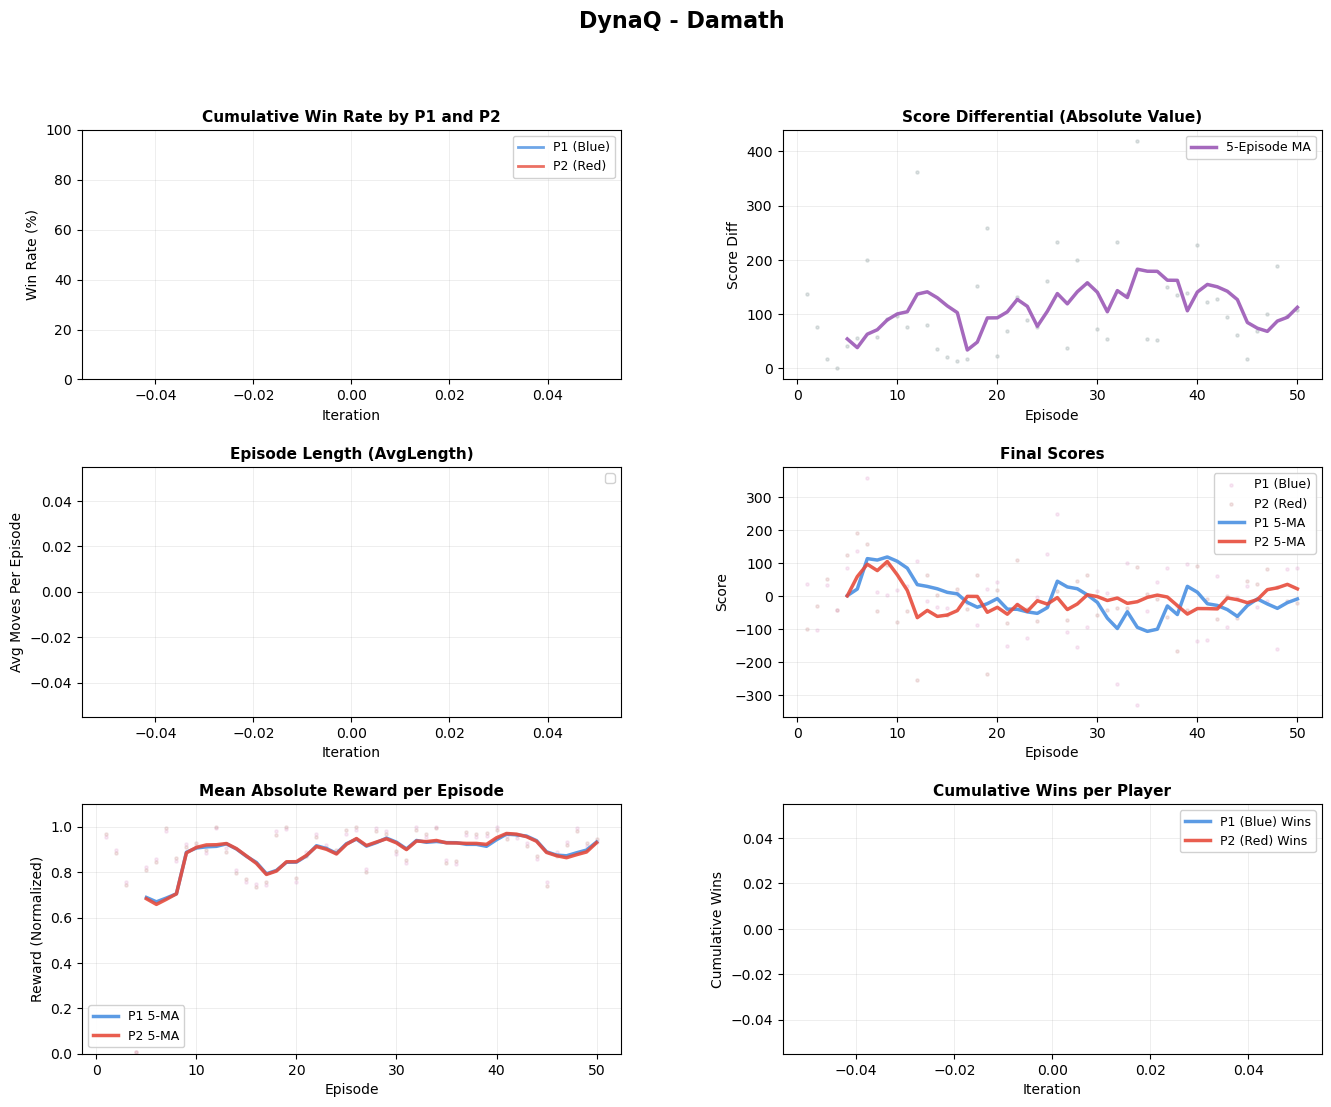

In [14]:
# Define env_factory function
def env_factory():
    return DamathEnv(rows=8, cols=8, operator_pattern=operator_pattern_official)

# Train with all the metrics and hyperparameters
q_net, model_net, agent, history = train_dynaq_with_viz(
    env_factory, 
    num_episodes=50,   # still training for 1000 episodes
    games_per_iter=10,
    epsilon=0.2,         # Exploration Rate
    alpha=0.01,         # Learning Rate
    gamma=0.5,           # Discount Factor
    planning_steps=10
)

# Play a visual game
play_game_visual(env_factory, agent)
plot_training_metrics(history)

In [15]:
# import torch

# # Method 1: Load the low discount checkpoint
# checkpoint = torch.load('DynaQ_LowDiscount.pth')

# # Method 2: Load the low learning rate checkpoint
# checkpoint = torch.load('DynaQ_LowLearning.pth')

# # See what's inside
# print(checkpoint.keys())
# # Output: dict_keys(['q_net', 'model_net', 'history', 'episodes_completed', ...])


In [16]:
# def load_trained_agent(checkpoint_path, device=None):
#     """Load a trained DynaQ agent from checkpoint"""
#     if device is None:
#         device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
#     # Load checkpoint
#     checkpoint = torch.load(checkpoint_path, map_location=device)
    
#     # Create networks
#     q_net = QNetwork().to(device)
#     model_net = ModelNetwork().to(device)
    
#     # Load trained weights
#     q_net.load_state_dict(checkpoint['q_net'])
#     model_net.load_state_dict(checkpoint['model_net'])
    
#     # Set to evaluation mode
#     q_net.eval()
#     model_net.eval()
    
#     # Create optimizer (needed for agent initialization)
#     model_optimizer = optim.Adam(model_net.parameters(), lr=0.001)
    
#     # Create agent
#     agent = DynaQAgent(
#         q_net=q_net,
#         model_net=model_net,
#         model_optimizer=model_optimizer,
#         epsilon=0.0,  # No exploration for evaluation
#         alpha=0.001,
#         gamma=0.95,
#         planning_steps=10
#     )
    
#     print(f"✅ Loaded agent from {checkpoint_path}")
#     if 'episodes_completed' in checkpoint:
#         print(f"   Trained on {checkpoint['episodes_completed']} episodes")
    
#     return agent, checkpoint

# # Usage
# agent_low_discount, checkpoint1 = load_trained_agent('DynaQ_LowDiscount.pth')
# agent_low_learning, checkpoint2 = load_trained_agent('DynaQ_LowLearning.pth')

In [17]:
# # Play a visual game with the loaded agent
# def env_factory():
#     return DamathEnv(rows=8, cols=8, operator_pattern=operator_pattern_official)

# # Test the low discount agent
# print("\n🎮 Testing Low Discount Agent:")
# winner1, scores1 = play_game_visual(env_factory, agent_low_discount)

# # Test the low learning rate agent
# print("\n🎮 Testing Low Learning Rate Agent:")
# winner2, scores2 = play_game_visual(env_factory, agent_low_learning)

In [18]:
# def agent_vs_agent(env_factory, agent1, agent2, num_games=10):
#     """Have two agents play against each other"""
#     wins = {1: 0, -1: 0, 0: 0}
    
#     for game_num in range(num_games):
#         env = env_factory()
#         move_count = 0
        
#         while not env.game_over() and move_count < 300:
#             # Player 1 uses agent1, Player -1 uses agent2
#             if env.to_move == 1:
#                 move, _ = agent1.select_action(env, training=False)
#             else:
#                 move, _ = agent2.select_action(env, training=False)
            
#             if move is None:
#                 break
            
#             env.apply_move(move)
#             move_count += 1
        
#         _, winner = env.final_scores_and_winner()
#         wins[winner] += 1
#         print(f"Game {game_num+1}: Winner = {winner}")
    
#     print(f"\n📊 Results after {num_games} games:")
#     print(f"   Agent 1 (P1) wins: {wins[1]}")
#     print(f"   Agent 2 (P2) wins: {wins[-1]}")
#     print(f"   Draws: {wins[0]}")
    
#     return wins

# # Compare the two trained agents
# print("\n⚔️ Low Discount vs Low Learning Rate:")
# results = agent_vs_agent(env_factory, agent_low_discount, agent_low_learning, num_games=10)